# Run system commands from Jupyter


# Using pgmpy with the Asia Bayesian Network
This notebook demonstrates how to use `pgmpy` to work with Bayesian networks. We will:
1. Load the Asia Bayesian Network from a BIF file
2. Visualize the network structure using different styles
3. Display Conditional Probability Tables (CPTs)
4. Interact with the graph by checking parents and children
5. Test d-separation to understand independencies in the network
6. Generate synthetic data from the Bayesian Network

In [1]:
# Import required libraries
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from pgmpy.readwrite import BIFReader
from pgmpy.sampling import BayesianModelSampling

/home/nigus-haile/anaconda3/envs/lab_exercises/lib/python3.14/site-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in a future release. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


## 1. Loading the Asia Bayesian Network


Let's print the BIF file as text.

In [2]:
# with open("asia.bif") as file:
# Using the specific file path
file_path = "/media/nigus-haile/Local/EDU/milano_bicocca/2nd_semester/Unsupervised/Lab/Lab08/asia.bif"

# Method 1: Simple read and print
with open(file_path, "r") as file:
    content = file.read()
    print(content)

network unknown {
}
variable asia {
  type discrete [ 2 ] { yes, no };
}
variable tub {
  type discrete [ 2 ] { yes, no };
}
variable smoke {
  type discrete [ 2 ] { yes, no };
}
variable lung {
  type discrete [ 2 ] { yes, no };
}
variable bronc {
  type discrete [ 2 ] { yes, no };
}
variable either {
  type discrete [ 2 ] { yes, no };
}
variable xray {
  type discrete [ 2 ] { yes, no };
}
variable dysp {
  type discrete [ 2 ] { yes, no };
}
probability ( asia ) {
  table 0.01, 0.99;
}
probability ( tub | asia ) {
  (yes) 0.05, 0.95;
  (no) 0.01, 0.99;
}
probability ( smoke ) {
  table 0.5, 0.5;
}
probability ( lung | smoke ) {
  (yes) 0.1, 0.9;
  (no) 0.01, 0.99;
}
probability ( bronc | smoke ) {
  (yes) 0.6, 0.4;
  (no) 0.3, 0.7;
}
probability ( either | lung, tub ) {
  (yes, yes) 1.0, 0.0;
  (no, yes) 1.0, 0.0;
  (yes, no) 1.0, 0.0;
  (no, no) 0.0, 1.0;
}
probability ( xray | either ) {
  (yes) 0.98, 0.02;
  (no) 0.05, 0.95;
}
probability ( dysp | bronc, either ) {
  (yes, yes) 0.9

We load the Bayesian network from the `asia.bif` file using `pgmpy`'s `BIFReader`.

In [3]:
# Load the Bayesian network from the BIF file
reader = BIFReader(file_path)
model = reader.get_model()

print("\n" + "="*60)
print("BAYESIAN NETWORK LOADED SUCCESSFULLY")
print("="*60)
print(f"Network name: {reader.network_name}")
print(f"Nodes ({model.number_of_nodes()}): {list(model.nodes())}")
print(f"Edges ({model.number_of_edges()}): {list(model.edges())}")


BAYESIAN NETWORK LOADED SUCCESSFULLY
Network name: unknown
Nodes (8): ['asia', 'tub', 'smoke', 'lung', 'bronc', 'either', 'xray', 'dysp']
Edges (8): [('asia', 'tub'), ('tub', 'either'), ('smoke', 'lung'), ('smoke', 'bronc'), ('lung', 'either'), ('bronc', 'dysp'), ('either', 'xray'), ('either', 'dysp')]


## 2. Visualizing the Network Graph (Different Styles)
We visualize the structure of the Bayesian network using both NetworkX and Graphviz.
- **NetworkX**: A simple visualization with Matplotlib
- **Graphviz**: A more polished and clear visualization

/tmp/ipykernel_10489/3110348774.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


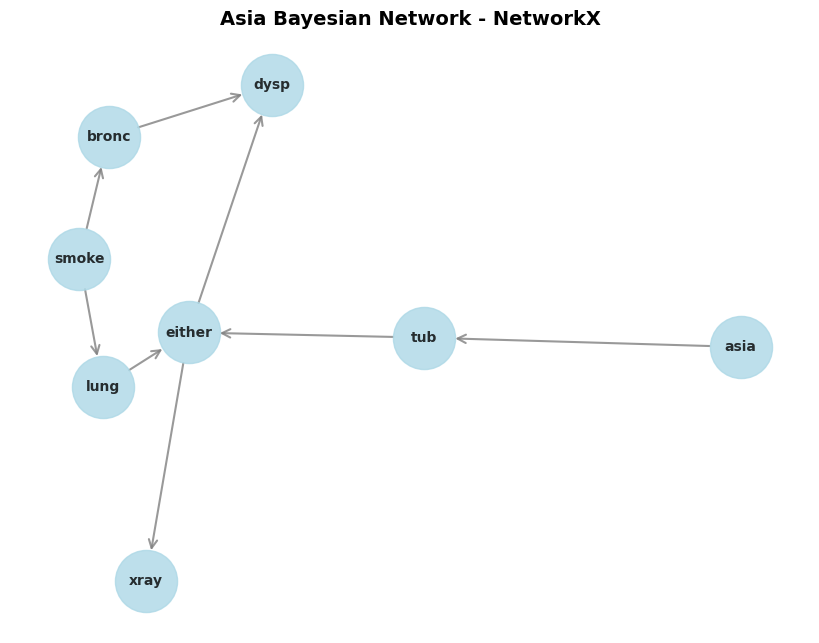

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

# Visualization using NetworkX
plt.figure(figsize=(8, 6))

# Create the graph edges based on your loaded model
edges = [('asia', 'tub'), ('tub', 'either'), ('smoke', 'lung'), 
         ('smoke', 'bronc'), ('lung', 'either'), ('bronc', 'dysp'), 
         ('either', 'xray'), ('either', 'dysp')]

# Create the graph
G = nx.DiGraph()
G.add_edges_from(edges)

# Draw the network
nx.draw(G, 
        with_labels=True,           # Show node labels
        node_color='lightblue',     # Node color
        node_size=2000,             # Node size
        font_size=10,               # Font size for labels
        font_weight='bold',         # Bold font for labels
        arrows=True,                # Show arrows for directed edges
        arrowsize=15,               # Arrow size
        arrowstyle='->',            # Arrow style
        edge_color='gray',          # Edge color
        width=1.5,                  # Edge width
        alpha=0.8)                  # Transparency

plt.title("Asia Bayesian Network - NetworkX", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_10489/872349491.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


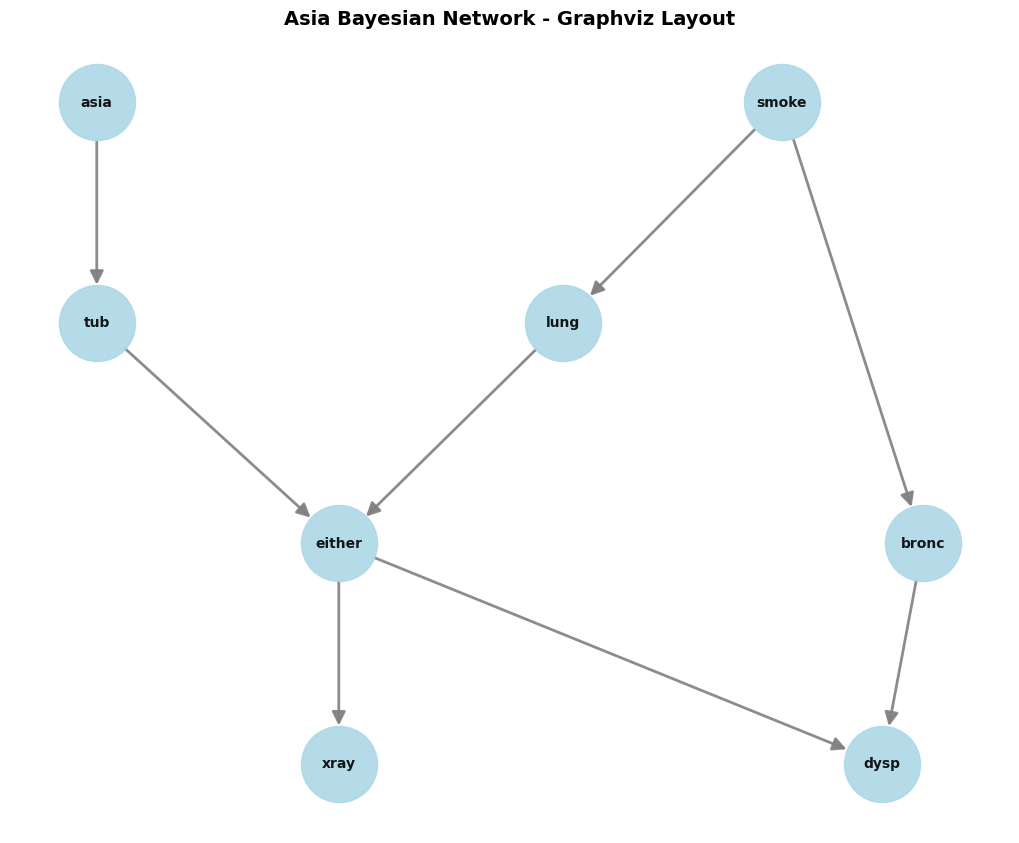

In [6]:
# Create the graph with edges from your model
edges = [('asia', 'tub'), ('tub', 'either'), ('smoke', 'lung'), 
         ('smoke', 'bronc'), ('lung', 'either'), ('bronc', 'dysp'), 
         ('either', 'xray'), ('either', 'dysp')]

G = nx.DiGraph()
G.add_edges_from(edges)

# Visualization using Graphviz layout
plt.figure(figsize=(10, 8))

# Use Graphviz dot layout for hierarchical tree structure
pos = nx.nx_agraph.graphviz_layout(G, prog='dot')

nx.draw(G, pos,
        with_labels=True,
        node_color='lightblue',
        node_size=3000,
        font_size=10,
        font_weight='bold',
        arrows=True,
        arrowsize=20,
        edge_color='gray',
        width=2,
        alpha=0.9)

plt.title("Asia Bayesian Network - Graphviz Layout", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Displaying Conditional Probability Tables (CPTs)
Each node in a Bayesian network has a Conditional Probability Table (CPT) that describes the probability distribution given its parents. Here, we display the CPTs for three variables: `tub`, `lung`, and `bronc`.

In [7]:
# Print CPTs for selected variables
variables_to_show = [ #... ]
for var in variables_to_show:
    # ...

## 4. Interacting with the Graph
We can query the network to find out the parents and children of specific variables. This helps us understand the relationships between nodes in the network.

In [8]:
# Get parents, children and Markov Blanket of selected nodes
print('\nGetting Parents, Children and Markov Blanket:')
for var in variables_to_show:
    # ...

## 5. Testing D-separation
D-separation helps determine whether two variables are independent given a set of observed variables. Here, we test d-separation for two pairs of variables in the network.

In [9]:
# Test d-separation between selected variable pairs
print('\nTesting D-separation:')
pairs_to_test = [('tub', 'lung'), #... ]
conditional_sets = [
    [],  # no observation
    ['asia'],  # observing asia
    # ...
]

# Test pairs with conditional sets
for (var1, var2) in pairs_to_test:
    # ...

Get the local independencies of the 'xray' node.

In [10]:
# List local independencies for a node
# ...

Get all the independencies implied by the model.

In [11]:
# Get all model implied independence conditions
# ...

## 6. Sampling from the Bayesian Network
A Bayesian Network can be used to generate synthetic data.

In [12]:
# Forward sampling from the Bayesian network

# Initialize the sampler with the Bayesian network model
# ...